# Auto-encodeur variationnel (VAE) — Fashion-MNIST

Meme comparaison que le notebook 05 original (AE classique vs VAE), rejouee sur T-shirt/top vs
Shirt. Le VAE ajoute a la reconstruction un terme KL qui pousse l'espace latent vers une
gaussienne centree reduite.

In [1]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 123

def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
set_seed()

In [2]:
data = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="auto")
X_all, y_all = data.data, data.target.astype(int)

mask = np.isin(y_all, [0, 6])
X = X_all[mask]
y = (y_all[mask] == 6).astype(int)  # 0 = T-shirt/top, 1 = Shirt
target_names = np.array(["T-shirt/top", "Shirt"])

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=SEED, stratify=y_trainval)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(X_train.shape, X_val.shape, X_test.shape)

(8400, 784) (2800, 784) (2800, 784)


In [3]:
Xtr = torch.from_numpy(X_train).float()
Xva = torch.from_numpy(X_val).float()
Xte = torch.from_numpy(X_test).float()
ytr = torch.from_numpy(y_train).long()
yva = torch.from_numpy(y_val).long()
yte = torch.from_numpy(y_test).long()

# batch_size 128 (vs 64 sur le cancer)
pretrain_loader = DataLoader(TensorDataset(Xtr), batch_size=128, shuffle=True)
val_pretrain_loader = DataLoader(TensorDataset(Xva), batch_size=128, shuffle=False)
train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(Xva, yva), batch_size=128, shuffle=False)
test_loader = DataLoader(TensorDataset(Xte, yte), batch_size=128, shuffle=False)

In [4]:
# encodeur/decodeur mis a l'echelle : 784 -> 256 -> 64 -> latent (au lieu de 30 -> 14 -> 6)
class Encodeur(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(),
            nn.Linear(256, 64),
            nn.LeakyReLU()
            )
        self.mu = nn.Linear(64, latent_dim)
        self.log_sigma = nn.Linear(64, latent_dim)
    def forward(self, x):
        shared = self.net(x)
        return self.mu(shared), self.log_sigma(shared)

class Decodeur(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 256),
            nn.LeakyReLU(),
            nn.Linear(256, 784)
        )
    def forward(self, z):
        return self.net(z)

class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encodeur = Encodeur(latent_dim)
        self.decodeur = Decodeur(latent_dim)

    def reparametrize(self, mu, log_sigma):
        # Dans un but d'inference (pas de generation qui est l'utilisation de base d'un VAE)
        # on predit simplement la moyenne sans echantilloner
        if self.training:
            std = torch.exp(0.5 * log_sigma)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def forward(self, x):
            mu, log_sigma = self.encodeur(x)
            z = self.reparametrize(mu, log_sigma)
            x_chap = self.decodeur(z)
            return x_chap, mu, log_sigma

In [5]:
def vae_loss(x, x_chap, mu, log_sigma):
    rec_loss = F.mse_loss(x_chap, x, reduction='none').sum(dim=1).mean()
    kl_loss = -0.5 * torch.mean(1 + log_sigma - mu**2 - torch.exp(log_sigma))
    return rec_loss + kl_loss

set_seed()

vae = VAE(latent_dim=2)
optimizer = torch.optim.AdamW(vae.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

# Early Stopping
patience = 15
min_delta = 1e-4
best_val_loss = float("inf")
patience_counter = 0
best_model_weights = None

epochs = 160
train_losses = []
val_losses = []

for epoch in range(epochs):
    vae.train()
    running_train = 0.0
    for (xb,) in pretrain_loader:
        optimizer.zero_grad()
        out, mu, log_sigma = vae(xb)
        loss = vae_loss(xb, out, mu, log_sigma)
        loss.backward()
        optimizer.step()
        running_train += loss.item() * xb.size(0)

    epoch_train_loss = running_train / len(pretrain_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Validation
    vae.eval()
    running_val = 0.0
    with torch.no_grad():
        for (xb,) in val_pretrain_loader:
            out, mu, log_sigma = vae(xb)
            loss = vae_loss(xb, out, mu, log_sigma)
            running_val += loss.item() * xb.size(0)

    epoch_val_loss = running_val / len(val_pretrain_loader.dataset)
    val_losses.append(epoch_val_loss)

    scheduler.step(epoch_val_loss)

    # Early stopping
    if epoch_val_loss < best_val_loss - min_delta:
        best_val_loss = epoch_val_loss
        best_model_weights = copy.deepcopy(vae.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 20 == 0 or patience_counter >= patience:
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch + 1:03d}/{epochs} Train Loss: {epoch_train_loss:.4f} Val Loss: {epoch_val_loss:.4f} LR: {current_lr:.1e}")

    if patience_counter >= patience:
        print(f"\nArret epoch {epoch + 1}. Meilleure Val Loss: {best_val_loss:.4f}")
        break

# Restauration des poids optimaux
if best_model_weights is not None:
    vae.load_state_dict(best_model_weights)

Epoch 020/160 Train Loss: 351.4622 Val Loss: 490.4723 LR: 1.0e-03


Epoch 040/160 Train Loss: 329.2571 Val Loss: 477.1763 LR: 1.0e-03


Epoch 060/160 Train Loss: 313.1721 Val Loss: 473.7308 LR: 5.0e-04


Epoch 080/160 Train Loss: 306.3541 Val Loss: 472.5268 LR: 6.3e-05


Epoch 082/160 Train Loss: 306.2359 Val Loss: 472.5072 LR: 6.3e-05

Arret epoch 82. Meilleure Val Loss: 472.4952


## Espace latent : AE vs VAE

Pour bien voir la difference de construction de l'espace, j'entraine aussi un auto-encodeur
classique (meme archi que le VAE mais sans le terme KL, latent 2), sur les memes donnees, puis
je trace les deux espaces latents cote a cote comme dans le notebook 01. Le VAE a un terme KL
qui pousse le latent vers une gaussienne centree reduite : on s'attend donc a un nuage plus
resserre et centre autour de (0, 0), la ou l'AE peut etaler le sien comme il veut.

In [6]:
# auto-encodeur classique de comparaison (meme archi que le VAE, sans le KL)
class AE_Encodeur(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256), nn.LeakyReLU(),
            nn.Linear(256, 64), nn.LeakyReLU(),
            nn.Linear(64, latent_dim))
    def forward(self, x):
        return self.net(x)

class AE_Decodeur(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.LeakyReLU(),
            nn.Linear(64, 256), nn.LeakyReLU(),
            nn.Linear(256, 784))
    def forward(self, z):
        return self.net(z)

class AE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encodeur = AE_Encodeur(latent_dim)
        self.decodeur = AE_Decodeur(latent_dim)
    def forward(self, x):
        return self.decodeur(self.encodeur(x))

# on l'entraine sur le meme train que le VAE (reconstruction simple)
set_seed()
ae = AE(latent_dim=2)
opt = torch.optim.AdamW(ae.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()
for epoch in range(160):
    ae.train()
    for (xb,) in pretrain_loader:
        opt.zero_grad()
        loss_fn(ae(xb), xb).backward()
        opt.step()

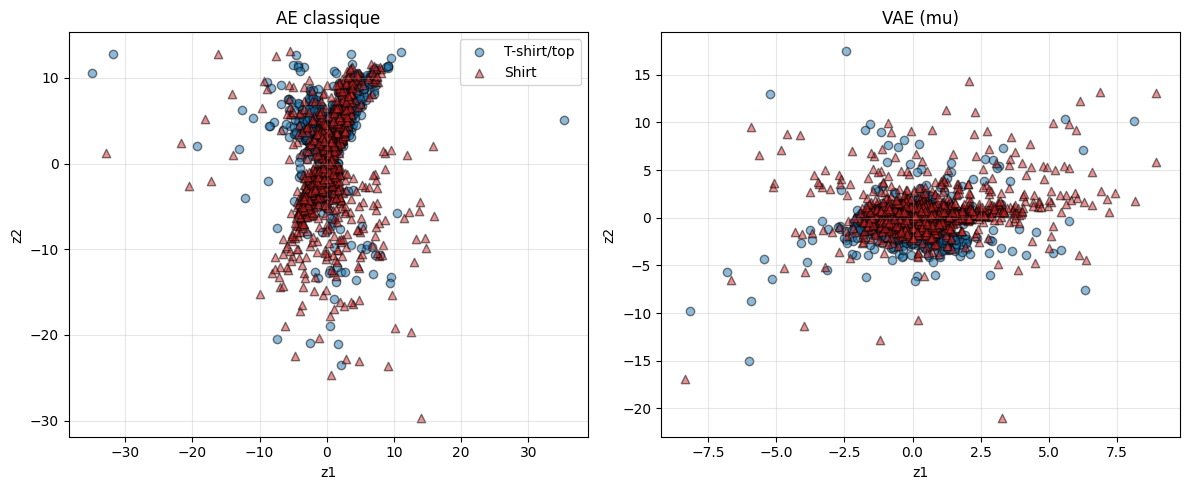

In [7]:
# comparaison visuelle des deux espaces latents sur le test
ae.eval(); vae.eval()
with torch.no_grad():
    Z_ae = ae.encodeur(Xte).numpy()
    mu_vae, _ = vae.encodeur(Xte)
    Z_vae = mu_vae.numpy()
Y = yte.numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)
for ax, Z, titre in [(axes[0], Z_ae, "AE classique"), (axes[1], Z_vae, "VAE (mu)")]:
    ax.scatter(Z[Y == 0, 0], Z[Y == 0, 1], c="tab:blue", alpha=0.5, edgecolors="k", label="T-shirt/top")
    ax.scatter(Z[Y == 1, 0], Z[Y == 1, 1], c="tab:red", alpha=0.5, edgecolors="k", marker="^", label="Shirt")
    ax.set_title(titre); ax.set_xlabel("z1"); ax.set_ylabel("z2"); ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.savefig("figures/latent_ae_vs_vae.png", dpi=130, bbox_inches="tight")
plt.show()

## Performance predictive : AE vs VAE

Meme protocole que le notebook 02 : on gele l'encodeur et on pose une petite tete de classif
par-dessus (linear probing), puis on regarde F1 macro et ROC-AUC sur le test. J'ajoute aussi le
full fine-tuning. Pour le VAE, la representation utilisee est mu.

In [8]:
# tete de classif branchee sur un encodeur.
# use_mu=True pour le VAE : son encodeur renvoie (mu, log_sigma), on garde mu
class Classifieur(nn.Module):
    def __init__(self, encodeur, latent_dim, freeze, use_mu):
        super().__init__()
        self.encodeur = encodeur
        self.use_mu = use_mu
        if freeze:
            for p in self.encodeur.parameters():
                p.requires_grad = False
        self.tete = nn.Sequential(
            nn.Linear(latent_dim, 8), nn.LeakyReLU(),
            nn.Linear(8, 2))
    def forward(self, x):
        z = self.encodeur(x)
        if self.use_mu:
            z = z[0]
        return self.tete(z)

def train_clf(model, epochs=80):
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                            lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad(set_to_none=True)
            loss_fn(model(xb), yb).backward()
            opt.step()
    return model

def test_scores(model):
    model.eval()
    yt, yp, pp = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb)
            pp.extend(torch.softmax(logits, dim=1)[:, 1].numpy())
            yp.extend(logits.argmax(dim=1).numpy())
            yt.extend(yb.numpy())
    yt, yp, pp = np.array(yt), np.array(yp), np.array(pp)
    return f1_score(yt, yp, average="macro"), roc_auc_score(yt, pp)

rows = []
for nom, enc_src, use_mu in [("AE", ae.encodeur, False), ("VAE", vae.encodeur, True)]:
    set_seed()
    probe = Classifieur(copy.deepcopy(enc_src), 2, freeze=True, use_mu=use_mu)
    train_clf(probe)
    f1p, aucp = test_scores(probe)

    set_seed()
    ft = Classifieur(copy.deepcopy(enc_src), 2, freeze=False, use_mu=use_mu)
    train_clf(ft)
    f1f, aucf = test_scores(ft)

    rows.append([nom, round(aucp, 3), round(f1p, 3), round(aucf, 3), round(f1f, 3)])

res = pd.DataFrame(rows, columns=["modele", "probing AUC", "probing F1", "full-ft AUC", "full-ft F1"])
print(res.to_string(index=False))

modele  probing AUC  probing F1  full-ft AUC  full-ft F1
    AE        0.869       0.803        0.943       0.873
   VAE        0.870       0.792        0.945       0.871


### A regarder

Sur l'espace latent, la difference est visible mais moins spectaculaire que prevu : le nuage du
VAE reste globalement dans [-10, 15] alors que l'AE classique etale quelques points jusqu'a
±30 — le terme KL retient les cas extremes sans pour autant produire un disque bien resserre
autour de (0, 0), probablement parce que les deux classes se chevauchent deja trop pour que la
regularisation "range" grand-chose de plus.

Sur la performance, les deux se tiennent d'extremement pres, comme sur le cancer : linear
probing a 0,870 de ROC-AUC pour le VAE contre 0,869 pour l'AE (F1 legerement en faveur de l'AE :
0,803 contre 0,792), et full fine-tuning a 0,945 contre 0,943. La regularisation du VAE ne coute
donc rien niveau prediction ici non plus, mais n'apporte rien de plus qu'un AE classique sur
cette tache de classification — la encore comme sur le cancer, son interet reel est ailleurs
(espace latent structure, generation), pas dans la classification pure. Le passage a un dataset
plus dur n'a donc pas change cette conclusion particuliere, contrairement a ce qu'on a vu pour
l'effet de la dimension latente (notebook 02) ou l'utilite du pre-entrainement (notebook 04).